# Combined notebook

## Contents

- [0 Setup And Intro](#0-setup-and-intro)
- [VQE tutorial](#vqe-tutorial)
- [Advanced 1 Precalculatedhamiltonians](#advanced-1-precalculatedhamiltonians)
- [Advanced 2 Customtargetbackend](#advanced-2-customtargetbackend)

In [ ]:
# Colab setup
from pathlib import Path
from urllib.request import urlretrieve
import sys

DOWNLOAD_DIR = Path(".")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

def _download(url: str, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    print(f'Downloading {url} -> {dst}')
    urlretrieve(url, dst)

resolved_download_dir = str(DOWNLOAD_DIR.resolve())
if resolved_download_dir not in sys.path:
    sys.path.insert(0, resolved_download_dir)

_download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/utils.py", Path("utils.py"))
_download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/linear_h_chains_bk_2q_reduced.json", Path("linear_h_chains_bk_2q_reduced.json"))
_download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/requirements.txt", Path("requirements.txt"))


# 0 Setup And Intro
<a id="0-setup-and-intro"></a>

_Source: `0_setup-and-intro.ipynb`_

## Installation

In [7]:
!pip install -r requirements.txt


-------------

## Save IBM Account
![IQP_login.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/IQP_login.png)
1. Login [IBM Quantum Platform](https://quantum.cloud.ibm.com/).
2. Create and copy API Key.
3. Generate an `.env` file and write a line as follows:
```
API_TOKEN=your_token
```


In [8]:
import os
from dotenv import load_dotenv
from qiskit_ibm_runtime import QiskitRuntimeService

load_dotenv()

api_token = os.getenv("API_TOKEN")
if not api_token:
    raise RuntimeError("API_TOKEN is not set")

QiskitRuntimeService.save_account(
    token=api_token,
    overwrite=True
)

-------------

## Useful Resources

- Qiskit and IBM Quantum Documentations [https://quantum.cloud.ibm.com/docs/en/guides](https://quantum.cloud.ibm.com/docs/en/guides)

### Release
- Qiskit 2.0 Release News [https://www.ibm.com/quantum/blog/qiskit-2-0-release-summary](https://www.ibm.com/quantum/blog/qiskit-2-0-release-summary)
- Qiskit 2.1 Release News [https://www.ibm.com/quantum/blog/qiskit-2-1-release-summary](https://www.ibm.com/quantum/blog/qiskit-2-1-release-summary)
- Qiskit 2.2 Release News [https://www.ibm.com/quantum/blog/qiskit-2-2-release-summary](https://www.ibm.com/quantum/blog/qiskit-2-1-release-summary)
- Qiskit 2.3 Release News [https://www.ibm.com/quantum/blog/qiskit-2-3-release-summary](https://www.ibm.com/quantum/blog/qiskit-2-1-release-summary)
- Full Release Notes [https://quantum.cloud.ibm.com/docs/en/api/qiskit/release-notes](https://quantum.cloud.ibm.com/docs/en/api/qiskit/release-notes)
- 1.x -> 2.x Migration Guide [https://quantum.cloud.ibm.com/docs/en/guides/qiskit-2.0](https://quantum.cloud.ibm.com/docs/en/guides/qiskit-2.0)

### Qiskit Ecosystem
- 

### Learning
- Qiskit Tutorials [https://quantum.cloud.ibm.com/docs/en/tutorials](https://quantum.cloud.ibm.com/docs/en/tutorials)



# VQE tutorial
<a id="vqe-tutorial"></a>

_Source: `2_vqe_tutorial_revised.ipynb`_

This notebook merges the IBM Quantum Learning VQE material with a ground-state workflow organized around the **Qiskit Pattern**:

1. **Map** the chemistry problem to a qubit Hamiltonian and ansatz  
2. **Optimize** by preparing ISA circuits and aligned observables  
3. **Execute** with Estimator / Sampler in appropriate execution modes  
4. **Post-process** with both **Estimator-based VQE** and **SQD-style projected diagonalization**

This version intentionally omits environment setup.

## Learning goals

By the end of the tutorial, you should be able to:

- build a compact four-qubit H₂ VQE workflow,
- prepare **ISA circuits** and apply the same layout to observables,
- choose between **job / session / batch** execution modes,
- compare **error-mitigation levels** and custom mitigation knobs,
- inspect transpilation on both a **real backend target** and a **custom `Target`** with user-defined error rates,
- compare the convergence of:
  - **Estimator-based VQE**, and
  - **SQD-style energy estimation from samples**.


## Suggested pacing for a 2-hour live tutorial

- 0:00–0:15 — Problem setup and Hamiltonian
- 0:15–0:35 — Estimator-based VQE in local mode
- 0:35–0:55 — ISA transpilation and observable layout
- 0:55–1:15 — Execution modes and mitigation strategy
- 1:15–1:40 — SQD-style projected diagonalization from samples
- 1:40–2:00 — Comparison, exercises, and discussion


In [38]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager


## 0. Variational Quantum Eigensolver (VQE) workflow

<center><img src="https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/vqe.avif" alt="vqe.avif" width="800"/></center>

VQE is a hybrid quantum-classical algorithm for estimating the ground-state energy of a Hamiltonian.  
Instead of diagonalizing the full Hamiltonian exactly, it prepares a parameterized trial state on a quantum circuit and optimizes those parameters so that the measured energy becomes as small as possible.

---------

### Typical VQE workflow

1. **Prepare the problem Hamiltonian**  
   Start from the molecular or spin Hamiltonian written as a sum of Pauli operators,
   $$
   H = \sum_i c_i P_i.
   $$
   This is the quantity whose ground-state energy we want to estimate.

2. **Choose a parameterized ansatz**  
   Construct a quantum circuit $ U(\theta) $ with tunable parameters $\theta$.  
   Acting on an initial state, it prepares a trial state
   $$
   |\psi(\theta)\rangle = U(\theta)|0\rangle.
   $$

3. **Measure the expectation value on a quantum computer**  
   For the current parameters, evaluate
   $$
   E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle.
   $$
   Since $H$ is decomposed into Pauli terms, this is done by measuring the corresponding Pauli observables and combining the results with their coefficients.

4. **Optimize the parameters classically**  
   A classical optimizer updates the parameters $ \theta $ to reduce the measured energy.

5. **Iterate until convergence**  
   The quantum processor and classical optimizer form a loop:
   prepare state $\rightarrow$ measure energy $\rightarrow$ update parameters.  
   When the energy stops improving, the final value approximates the ground-state energy, and the optimized circuit approximates the ground state.

This hybrid structure is what makes VQE attractive for near-term quantum devices: the quantum computer handles state preparation and measurement, while the classical computer handles parameter optimization.

---------------------

### VQE workflow in the Qiskit pattern

The implementation of VQE can be understood through the **Qiskit pattern**, which organizes quantum applications into four stages: **map**, **optimize**, **execute**, and **post-process**.
In IBM Quantum’s terminology, these correspond to: mapping the problem to quantum circuits and operators, optimizing for target hardware, executing on target hardware, and post-processing results.


**map**: prepares the qubit Hamiltonian and choosing a parameterized ansatz circuit.

**optimize**: transpiles that ansatz into an ISA circuit suitable for the selected backend, including layout selection and basis-gate conversion.

**execute**: estimate the energy expectation value for a given parameter set, typically using the `Estimator` primitive, which returns observable expectation values.  

**post-process**: uses those measured energies in a classical optimization loop to update the variational parameters and check convergence.


![VQE in Qiskit Pattern](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/vqe_qiskit_pattern.png)

--------

## 1. Map: Problem Hamiltonian and Ansatz


### Hamiltonian
We use the precalculated **2-qubit H₂ Hamiltonian**.
The molecular Hamiltonian is derived from a classical electronic-structure calculation, called Hartree-Fock method with **STO-3G** atomic orbital basis set.
It is then mapped to Pauli operator with symmetry-preserving Bravyi-Kitaev transformation ([arXiv:1208.5986](https://arxiv.org/abs/1208.5986), [arXiv:1701.08213](https://arxiv.org/abs/1701.08213)).

![mol_mapping.jpg](https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/mol_mapping.jpg)

In [39]:
H2_ham = SparsePauliOp(
    ['II', 'IZ', 'ZI', 'ZZ', 'XX'],
    coeffs=[-0.33995361+0.j,  0.39398368+0.j,  0.39398368+0.j,  0.01123659+0.j, 0.18128881+0.j],
)

H2_matrix = H2_ham.to_matrix()
print("Hamiltonian matrix:\n", H2_matrix)

exact_evals = np.linalg.eigvalsh(H2_matrix)
exact_gnd = float(np.min(exact_evals))

print(f"Exact ground-state energy: {exact_gnd:.10f}")
print(f"Number of qubits: {H2_ham.num_qubits}")

Hamiltonian matrix:
 [[ 0.45925034+0.j  0.        +0.j  0.        +0.j  0.18128881+0.j]
 [ 0.        +0.j -0.3511902 +0.j  0.18128881+0.j  0.        +0.j]
 [ 0.        +0.j  0.18128881+0.j -0.3511902 +0.j  0.        +0.j]
 [ 0.18128881+0.j  0.        +0.j  0.        +0.j -1.11668438+0.j]]
Exact ground-state energy: -1.1372701679
Number of qubits: 2


Even though this H₂ Hamiltonian is still small enough (4×4) to be diagonalized exactly on a laptop, the matrix size and the classical computational cost grow very quickly as the molecular system becomes larger.
The Hilbert space dimension and the size of the many-body Hamiltonian increase exponentially with the number of considered orbitals, and therefore with the number of qubits.
As an example, a free benzene molecule in the STO-3G basis involves 72 spin orbitals, so the possible Fock basis states scale as $2^{72}\approx 4.7\times 10^{21}$!

H₂ is the minimal example for learning the workflow, while larger molecules rapidly demand much more classical memory and compute.
For a broader view, see [advanced-1_PrecalculatedHamiltonians.ipynb](#advanced-1-precalculatedhamiltonians), which shows the classical calculation and qubit Hamiltonians for hydrogen chains of increasing size.


### Ansatz
To search for the ground state variationally, we next choose a parameterized quantum circuit, or ansatz, to represent a family of trial states.
The optimizer will tune the circuit parameters so that the expectation value of the Hamiltonian becomes as small as possible.

In this example, we use the hardware-efficient [`efficient_su2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2) ansatz provided by Qiskit.
It builds a layered circuit of single-qubit rotations and entangling gates, giving a flexible
but hardware-friendly parametrization for small VQE demonstrations.

Other ansatz choice include
- [`excitation_preserving`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.excitation_preserving): Preserves number of `1`s in the computational basis state. This is often useful for mappings such as Jordan-Wigner.
- [`evolved_operator_ansatz`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.evolved_operator_ansatz): Usually for quantum-chemistry-inspired ansatz, such as unitary coupled cluster.
- [`n_local`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.n_local): Construct an $n$-local variational circuit.
- [More ansatz circuits](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library#n-local-circuits)

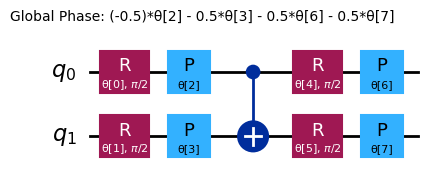

In [40]:
ansatz = efficient_su2(
    num_qubits=H2_ham.num_qubits,
    reps=1,
    entanglement="linear",
    su2_gates=["ry", "rz"],
    insert_barriers=False,
)
ansatz.decompose().draw("mpl", idle_wires=False)

In [41]:
num_params = ansatz.num_parameters
x0 = np.ones(num_params) * np.pi/2
print("Number of ansatz parameters:", num_params)

Number of ansatz parameters: 8


------------------

## Abstract and Ideal Setup - Running on Local Emulator

We first work in purely local mode with `StatevectorEstimator` so that the optimization logic is easy to inspect.

Later we will switch to the **Qiskit Pattern** view:
- abstract circuit / observable (Already done in Section 1),
- transpiled **ISA circuit**,
- layout-applied **ISA observable**,
- execution via `Estimator` or `Sampler`.


In [42]:
estimator_sv = StatevectorEstimator()

def estimate_energy_sv(theta):
    pub = (ansatz, H2_ham, theta)
    result = estimator_sv.run([pub]).result()
    return float(np.real(result[0].data.evs))

energy_history = []
param_history = []

def callback_store(xk):
    param_history.append(np.array(xk, dtype=float))
    energy_history.append(estimate_energy_sv(xk))

res = minimize(
    estimate_energy_sv,
    x0=x0,
    method="POWELL",
    callback=callback_store,
    options={"maxiter": 100, "disp": True},
)

vqe_theta = np.array(res.x, dtype=float)
vqe_energy = float(res.fun)

print(res.message)
print(f"Final VQE electronic energy: {vqe_energy:.10f}")
print(f"Exact electronic energy:     {exact_gnd:.10f}")
print(f"Absolute error:              {abs(vqe_energy-exact_gnd):.3e}")


Optimization terminated successfully.
         Current function value: -1.137225
         Iterations: 9
         Function evaluations: 721
Optimization terminated successfully.
Final VQE electronic energy: -1.1372251996
Exact electronic energy:     -1.1372701679
Absolute error:              4.497e-05


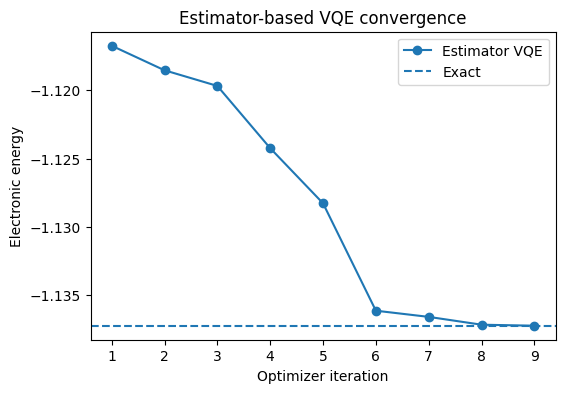

In [43]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(energy_history)+1), energy_history, marker="o", label="Estimator VQE")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator-based VQE convergence")
plt.legend()
plt.show()



--------

## 2. Optimization: Mapping to ISA and Transpilation

The ansatz we constructed above is still an abstract circuit, but real hardware can only run circuits that match its supported basis gates and qubit connectivity. Qiskit therefore uses transpilation to convert the ansatz into an **ISA circuit**, which is the hardware-compatible form required for execution on IBM Quantum backends.

In the next cell, we first connect to the IBM Quantum service and select a real device with enough qubits for the demonstration.  

In [49]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
# This may take a few seconds as it fetches the latest backend information.
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
# Or by name:
backend = service.backend("test_eagle_eu-de")

print("Selected backend:", backend.name)
print("Backend gate set:", backend.operation_names)
print("Backend coupling map:", backend.coupling_map)
# Graphic view (backend.coupling_map.draw()) is not possible without further installation of Graphvis.

qiskit_runtime_service.__init__:WARNING:2026-03-24 17:31:21,245: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (internal, premium), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-24 17:31:21,246: Using instance: Solutions Demo internal fleet, plan: internal


Selected backend: test_eagle_eu-de
Backend gate set: ['x', 'measure', 'rz', 'id', 'reset', 'delay', 'ecr', 'sx', 'if_else']
Backend coupling map:


RuntimeError: Graphviz could not be found or run. This function requires that Graphviz is installed. If you need to install Graphviz you can refer to: https://graphviz.org/download/#executable-packages for instructions.

We then generate a preset pass manager with ([`generate_preset_pass_manager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager)), including layout selection, routing, basis-gate translation, and circuit optimization.
This generates a preset [`PassManager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.PassManager), which manages a set of Passes and their schedule during transpilation.

<center><img src="https://raw.githubusercontent.com/snow0369/qiskit_handson_260330/main/images/transpiling_core_steps.avif" alt="transpiling_core_steps.avif" width="600"/></center>

Here we use `optimization_level=3` to request the heaviest built-in optimization level, and `seed_transpiler=1234` to make the stochastic parts of transpilation reproducible.

After transpilation, the circuit may no longer use the original logical qubit ordering, because the transpiler can choose a new layout to better match the hardware.  
For that reason, the Hamiltonian must also be updated to the same layout.
Qiskit’s `SparsePauliOp.apply_layout(...)` performs exactly this step, ensuring that the observable is aligned with the transpiled ansatz before expectation values are evaluated. 

Finally, we inspect a few basic properties of the resulting ISA circuit, such as its depth, total size, operation counts, and final qubit layout.  
These quantities give a first impression of how costly the ansatz becomes after hardware-aware compilation, and they are often useful when comparing different ansätze or transpilation settings.

Pass manager stages: ('init', 'layout', 'routing', 'translation', 'optimization', 'scheduling')
ISA depth: 15
ISA size: 27
ISA operations: OrderedDict({'rz': 17, 'sx': 9, 'ecr': 1})
Layout: Layout({
	4: <Qubit register=(2, "q"), index=0>,
	3: <Qubit register=(2, "q"), index=1>,
	0: <Qubit register=(125, "ancilla"), index=0>,
	1: <Qubit register=(125, "ancilla"), index=1>, 
	...
	})
Transpiled Circuit:


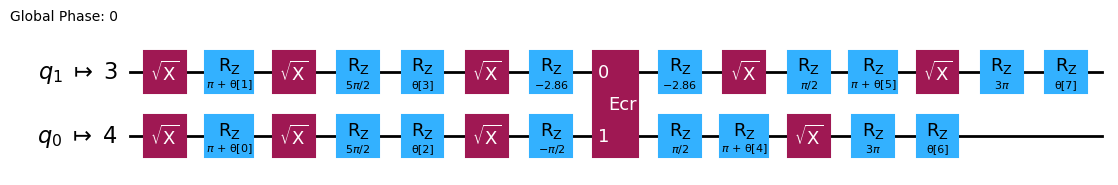

In [45]:
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
    seed_transpiler=1234,
)
print("Pass manager stages:", pm.stages)
isa_ansatz = pm.run(ansatz)
isa_hamiltonian = H2_ham.apply_layout(isa_ansatz.layout)

print("ISA depth:", isa_ansatz.depth())
print("ISA size:", isa_ansatz.size())
print("ISA operations:", isa_ansatz.count_ops())
print("Layout:", '\n\t'.join(repr(isa_ansatz.layout.initial_layout).splitlines()[:5]), "\n\t...\n\t})")
print("Transpiled Circuit:")
isa_ansatz.draw("mpl", idle_wires=False)

## 3. Execution

The IBM Runtime execution modes are:

- **job**: simplest, best for a single primitive request,
- **session**: best for iterative workloads like VQE,
- **batch**: best for submitting many related jobs together, such as mitigation sweeps or parameter sweeps.

For a VQE tutorial, the modes can be mapped to the following purposes.

1. **Job mode** — one single-point energy evaluation  
2. **Session mode** — the actual iterative VQE loop  
3. **Batch mode** — compare mitigation settings or optimizer restarts in parallel


In [46]:
# Optional Runtime templates.
#
# from qiskit_ibm_runtime import (
#     QiskitRuntimeService,
#     EstimatorV2 as Estimator,
#     Session,
#     Batch,
# )
#
# service = QiskitRuntimeService()
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=4)
#
# pm = generate_preset_pass_manager(backend=backend, optimization_level=3, seed_transpiler=1234)
# isa_ansatz = pm.run(ansatz)
# isa_hamiltonian = H4.apply_layout(isa_ansatz.layout)
#
# # 1) Job mode: one single energy evaluation
# estimator_job = Estimator(mode=backend, options={"resilience_level": 0})
# job = estimator_job.run([(isa_ansatz, isa_hamiltonian, [vqe_theta])])
#
# # 2) Session mode: best for iterative VQE
# with Session(backend=backend) as session:
#     estimator_sess = Estimator(mode=session, options={"resilience_level": 1})
#     # repeated estimator_sess.run(...) calls for optimizer iterations
#
# # 3) Batch mode: compare several mitigation levels in one grouped submission
# with Batch(backend=backend) as batch:
#     estimator_batch = Estimator(mode=batch)
#     pubs = [
#         (isa_ansatz, isa_hamiltonian, [vqe_theta]),
#     ]
#     # submit separate runs with different option objects or different PUB sets


### Execution-mode rule of thumb for this tutorial

- Use **job** mode when you are only demonstrating one or two energy evaluations.
- Use **session** mode for the main VQE loop because the classical optimizer repeatedly calls Estimator.
- Use **batch** mode when comparing:
  - multiple optimizers,
  - multiple starting points,
  - multiple mitigation settings,
  - or multiple geometries.


## 8. Error mitigation: simple levels and custom knobs

For a teaching notebook, it helps to separate mitigation into three layers:

### Level A — no mitigation
Use this as the baseline:
- `resilience_level = 0`

### Level B — light mitigation
Good first practical upgrade:
- `resilience_level = 1`
- TREX / measurement mitigation
- measurement twirling

### Level C — stronger mitigation
More overhead, potentially better accuracy:
- `resilience_level = 2`
- level 1 + gate twirling + ZNE

Then discuss **custom knobs** separately:
- dynamical decoupling,
- gate twirling,
- measurement twirling,
- measurement mitigation,
- ZNE,
- experimental PEA when available.


In [47]:
# Optional Runtime mitigation presets.
#
# from qiskit_ibm_runtime import EstimatorV2 as Estimator
#
# # Baseline
# est_L0 = Estimator(mode=backend, options={"resilience_level": 0})
#
# # Light mitigation
# est_L1 = Estimator(mode=backend, options={"resilience_level": 1})
#
# # Stronger mitigation
# est_L2 = Estimator(mode=backend, options={"resilience_level": 2})
#
# # More explicit / custom example
# est_custom = Estimator(mode=backend)
# est_custom.options.resilience_level = 0
# est_custom.options.dynamical_decoupling.enable = True
# est_custom.options.dynamical_decoupling.sequence_type = "XY4"
# est_custom.options.twirling.enable_gates = True
# est_custom.options.twirling.enable_measure = True
# est_custom.options.resilience.measure_mitigation = True
# est_custom.options.resilience.zne_mitigation = True
# # Experimental on supported configurations:
# # est_custom.options.resilience.pec_mitigation = True
# # est_custom.options.resilience.zne.amplifier = "pea"


### Recommended in-class experiment

At a fixed parameter vector `vqe_theta`, compare the same energy estimate under:

1. `resilience_level = 0`  
2. `resilience_level = 1`  
3. `resilience_level = 2`  
4. one custom configuration with DD + twirling + measurement mitigation  

Then discuss:
- bias reduction,
- shot overhead,
- wall-clock overhead,
- and which setting is appropriate for a real iterative optimization loop.


### Exercise 5

Which mitigation setting would you choose for each case?

1. A quick classroom demo with limited time  
2. A serious VQE run with repeated optimizer calls  
3. A final high-quality validation at the optimized parameter point


**Your notes:**


## 9. SQD-style ground-state estimation from samples

Now we add a **sample-based diagonalization** perspective.

For this small 4-qubit example, we implement a lightweight SQD-style routine directly:
1. prepare a trial state from the ansatz parameters,
2. sample computational-basis bitstrings,
3. form the subspace spanned by the observed bitstrings,
4. project the Hamiltonian onto that subspace,
5. diagonalize the projected matrix,
6. take the lowest eigenvalue as the SQD estimate.

This is intentionally minimal. The full SQD workflow in the IBM material and Qiskit addon adds more sophisticated ingredients such as configuration recovery and scalable classical solvers.


In [48]:
sampler_sv = StatevectorSampler()
basis_labels = [format(i, "04b") for i in range(2**H4.num_qubits)]

def sample_counts_from_params(theta, shots=4000, seed=1234):
    qc = ansatz.assign_parameters(theta)
    qc_m = qc.copy()
    qc_m.measure_all()
    job = sampler_sv.run([(qc_m,)], shots=shots, seed=seed)
    result = job.result()[0]
    # StatevectorSampler returns BitArray data per classical register.
    # Convert to counts in a robust, version-tolerant way.
    try:
        counts = result.data.meas.get_counts()
    except Exception:
        try:
            counts = result.data.c.get_counts()
        except Exception:
            counts = result.join_data().get_counts()
    return counts

def sqd_energy_from_counts(counts, hamiltonian_matrix):
    if len(counts) == 0:
        raise ValueError("No sampled bitstrings were provided.")
    selected = sorted(int(bitstr.replace(" ", ""), 2) for bitstr in counts.keys())
    proj = hamiltonian_matrix[np.ix_(selected, selected)]
    evals = np.linalg.eigvalsh(proj)
    return float(np.min(evals)), selected

# quick test at the optimized parameters
counts_test = sample_counts_from_params(vqe_theta, shots=4000, seed=7)
sqd_energy_test, sqd_basis_test = sqd_energy_from_counts(counts_test, h4_matrix)

print(f"SQD-style electronic energy at optimized parameters: {sqd_energy_test:.10f}")
print(f"Exact electronic energy:                           {exact_electronic:.10f}")
print(f"Number of sampled basis states in subspace:       {len(sqd_basis_test)}")


NameError: name 'H4' is not defined

## 10. Compare convergence: Estimator-VQE vs SQD-style projection

To compare apples to apples, we reuse the parameter vectors visited during the Estimator-based optimization.

At each optimizer iterate:
- **Estimator curve**: expectation value of the Hamiltonian  
- **SQD curve**: projected minimum eigenvalue obtained from samples drawn from the same trial state


In [ ]:
sqd_history = []
subspace_sizes = []

for k, theta in enumerate(param_history, start=1):
    counts_k = sample_counts_from_params(theta, shots=2000, seed=1000 + k)
    e_sqd_k, subspace_k = sqd_energy_from_counts(counts_k, h4_matrix)
    sqd_history.append(e_sqd_k)
    subspace_sizes.append(len(subspace_k))


In [ ]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(energy_history)+1), energy_history, marker="o", label="Estimator VQE")
plt.plot(range(1, len(sqd_history)+1), sqd_history, marker="s", label="SQD-style projected energy")
plt.axhline(exact_electronic, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator vs SQD-style convergence")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(subspace_sizes)+1), subspace_sizes, marker="o")
plt.xlabel("Optimizer iteration")
plt.ylabel("Sampled subspace dimension")
plt.title("SQD sampled subspace size along the VQE trajectory")
plt.show()


### Interpreting the comparison

Typical behavior to look for:

- **Estimator-VQE** gives the variational expectation value of the trial state.
- **SQD-style projection** can produce a better estimate from the *same sampled state support* because it diagonalizes in the sampled subspace.
- The SQD estimate is naturally tied to the quality of the sampled support: if important basis states never appear, the projected subspace misses part of the true ground state.
- In realistic noisy settings, SQD can be more noise-tolerant because bad samples can be down-weighted by the classical diagonalization stage.


### Exercise 6

From the plot, identify a regime where the SQD-style estimate improves faster or differently than the direct Estimator energy.

What does that suggest about the role of **support discovery** vs **expectation estimation**?


**Your notes:**


## 11. Optional: finite-shot study for the SQD comparison

The next cell lets you vary the sample budget and see how the SQD projected energy changes.


In [ ]:
shot_grid = [100, 250, 500, 1000, 2000, 4000, 8000]
sqd_vs_shots = []

for shots in shot_grid:
    counts = sample_counts_from_params(vqe_theta, shots=shots, seed=999)
    e_sqd, subspace = sqd_energy_from_counts(counts, h4_matrix)
    sqd_vs_shots.append((shots, e_sqd, len(subspace)))

sqd_vs_shots


In [ ]:
shots = [x[0] for x in sqd_vs_shots]
energies = [x[1] for x in sqd_vs_shots]
dims = [x[2] for x in sqd_vs_shots]

plt.figure(figsize=(6, 4))
plt.plot(shots, energies, marker="o")
plt.axhline(exact_electronic, linestyle="--")
plt.xscale("log")
plt.xlabel("Shots")
plt.ylabel("SQD-style electronic energy")
plt.title("SQD-style estimate vs sample budget")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(shots, dims, marker="o")
plt.xscale("log")
plt.xlabel("Shots")
plt.ylabel("Subspace dimension")
plt.title("Sampled subspace size vs sample budget")
plt.show()


## 12. Where the full SQD workflow goes beyond this notebook

This notebook uses a deliberately lightweight SQD-style implementation for pedagogical clarity.

The full IBM / Qiskit-addon SQD workflow additionally brings in:
- more problem-structured ansätze,
- repeated sample refinement,
- configuration recovery,
- symmetry / particle-number post-selection,
- scalable projected diagonalization,
- and HPC-oriented classical components for larger instances.


## 13. Challenge exercises

1. Replace `efficient_su2` with a chemistry-motivated ansatz and compare:
   - parameter count,
   - transpiled depth,
   - optimizer stability,
   - SQD sampled support.

2. Run several optimizer restarts and submit them in **batch mode**.

3. At the final parameter point, compare:
   - no mitigation,
   - resilience level 1,
   - resilience level 2,
   - one custom mitigation configuration.

4. Use a real backend target and a custom `Target` side by side:
   - compare basis gates,
   - compare coupling constraints,
   - compare expected failure points.

5. Add a post-selection filter to the SQD sample set and study how the projected energy changes.


## 14. Takeaways

- VQE fits naturally into the **Qiskit Pattern**: map → optimize → execute → post-process.
- For iterative optimization, **session** mode is usually the right Runtime choice.
- **Batch** mode is excellent for mitigation sweeps, restarts, and parameter studies.
- **ISA circuits** and **layout-aligned observables** are the core hardware-facing objects.
- Error mitigation should be taught as a **cost/accuracy trade-off**, not a magic switch.
- SQD provides a complementary view: use the quantum processor to discover important basis-state support, then let classical diagonalization extract better energy information from that support.


# Advanced 1 Precalculatedhamiltonians
<a id="advanced-1-precalculatedhamiltonians"></a>

_Source: `advanced-1_PrecalculatedHamiltonians.ipynb`_

In [6]:
from utils import load_sparse_pauli_ops_from_pickle

In [7]:
loaded_ham = load_sparse_pauli_ops_from_pickle(f"linear_h_chains_bk_2q_reduced.json")
print(f"Precalculated molecules = {list(loaded_ham.keys())}")

Precalculated molecules = ['H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8']


In [8]:
loaded_ham["H2"]

SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-0.33995361+0.j,  0.39398368+0.j,  0.39398368+0.j,  0.01123659+0.j,
  0.18128881+0.j])

In [ ]:
import numpy as np
from time import time

computation_times = list()

for n_chain in [2, 3, 4, 5, 6, 7, 8]: # n_chain = 8 takes too long to compute (>30mins):
    ham = loaded_ham[f"H{n_chain}"]
    print(f"Calculating the ground state energy of H{n_chain}...")
    print(f"n_qubits = {ham.num_qubits}, n_terms = {len(ham)}")
    mat = np.array(ham)
    print("Dimension of the Hamiltonian matrix is ", mat.shape)
    t = time()
    eigenvalues, eigenvectors = np.linalg.eigh(mat)

    computation_time = time() - t
    computation_times.append(computation_time)

    print("The ground state energy is ", min(eigenvalues), "hartrees")
    print("Computation time: ", computation_time, "seconds")
    print("")

Calculating the ground state energy of H2...
n_qubits = 2, n_terms = 5
Dimension of the Hamiltonian matrix is  (4, 4)
The ground state energy is  -1.137270174660903 hartrees
Computation time:  0.024614572525024414 seconds

Calculating the ground state energy of H3...
n_qubits = 4, n_terms = 52
Dimension of the Hamiltonian matrix is  (16, 16)
The ground state energy is  -1.5269470051364777 hartrees
Computation time:  0.0 seconds

Calculating the ground state energy of H4...
n_qubits = 6, n_terms = 165
Dimension of the Hamiltonian matrix is  (64, 64)
The ground state energy is  -2.13979964472261 hartrees
Computation time:  0.0019655227661132812 seconds

Calculating the ground state energy of H5...
n_qubits = 8, n_terms = 444
Dimension of the Hamiltonian matrix is  (256, 256)
The ground state energy is  -2.5582083207653468 hartrees
Computation time:  0.09498453140258789 seconds

Calculating the ground state energy of H6...
n_qubits = 10, n_terms = 919
Dimension of the Hamiltonian matrix i

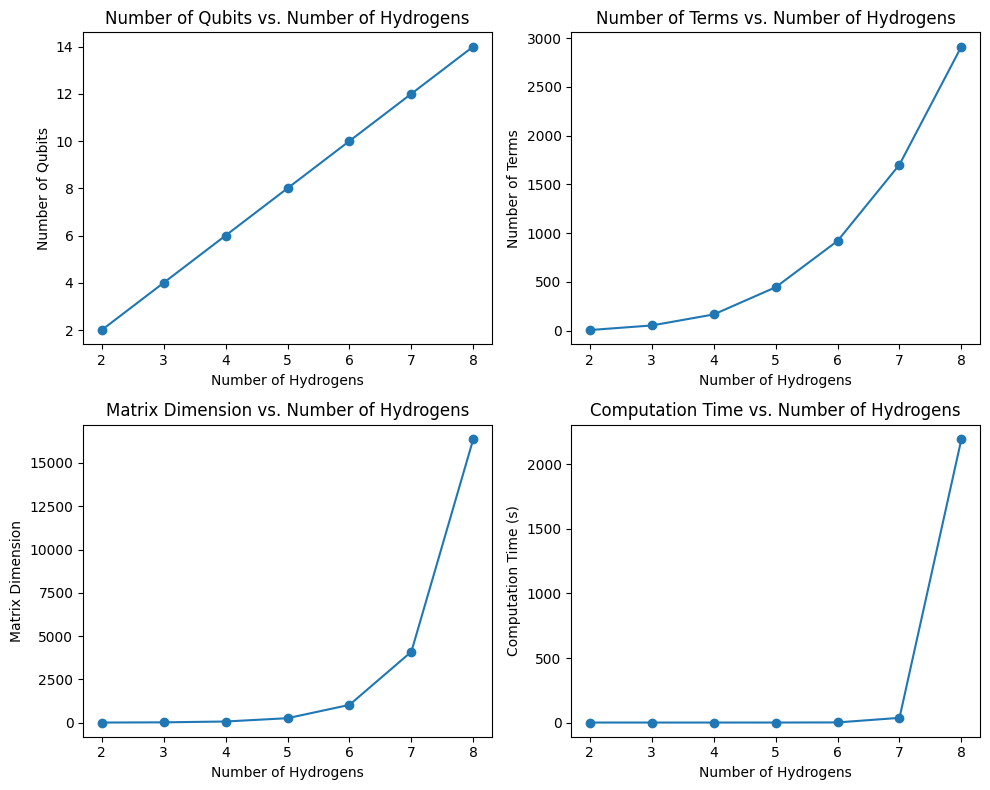

In [11]:
import matplotlib.pyplot as plt

# Collect data for each number of hydrogens (n_chain from 2 to 7)
n_chains = list(range(2, 9))
n_qubits_list = [loaded_ham[f"H{n}"].num_qubits for n in n_chains]
n_terms_list = [len(loaded_ham[f"H{n}"]) for n in n_chains]
dimensions_list = [np.array(loaded_ham[f"H{n}"]).shape[0] for n in n_chains]
times_list = computation_times  # Already computed in the previous cell

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot number of qubits
axs[0, 0].plot(n_chains, n_qubits_list, marker='o')
axs[0, 0].set_title('Number of Qubits vs. Number of Hydrogens')
axs[0, 0].set_xlabel('Number of Hydrogens')
axs[0, 0].set_ylabel('Number of Qubits')

# Plot number of terms
axs[0, 1].plot(n_chains, n_terms_list, marker='o')
axs[0, 1].set_title('Number of Terms vs. Number of Hydrogens')
axs[0, 1].set_xlabel('Number of Hydrogens')
axs[0, 1].set_ylabel('Number of Terms')

# Plot matrix dimension
axs[1, 0].plot(n_chains, dimensions_list, marker='o')
axs[1, 0].set_title('Matrix Dimension vs. Number of Hydrogens')
axs[1, 0].set_xlabel('Number of Hydrogens')
axs[1, 0].set_ylabel('Matrix Dimension')

# Plot computation time
axs[1, 1].plot(n_chains, times_list, marker='o')
axs[1, 1].set_title('Computation Time vs. Number of Hydrogens')
axs[1, 1].set_xlabel('Number of Hydrogens')
axs[1, 1].set_ylabel('Computation Time (s)')

plt.tight_layout()
plt.show()

# Advanced 2 Customtargetbackend
<a id="advanced-2-customtargetbackend"></a>

_Source: `advanced-2_CustomTargetBackend.ipynb`_

In [ ]:
from qiskit import transpile
from qiskit.circuit import ParameterVector
from qiskit.transpiler import Target, InstructionProperties
from qiskit.circuit.library import RZGate, SXGate, XGate, Measure, ECRGate

## Compare transpilation on a custom `Target`

A `Target` lets us define a backend-like ISA ourselves, including:
- supported instructions,
- coupling constraints,
- durations,
- and **error rates**.

This is useful for:
- sensitivity studies,
- teaching,
- prototyping custom hardware assumptions,
- and explaining why the transpiler chooses certain decompositions.


In [ ]:
def make_custom_target(
    n_qubits=4,
    ecr_error=0.01,
    sx_error=2e-4,
    x_error=2e-4,
    meas_error=0.02,
    ecr_duration=5.0e-7,
    sx_duration=3.5e-8,
    x_duration=3.5e-8,
    meas_duration=1.2e-6,
):
    theta = ParameterVector("θ_target", 1)[0]
    target = Target(num_qubits=n_qubits)

    target.add_instruction(
        RZGate(theta),
        {(q,): None for q in range(n_qubits)},
        name="rz",
    )
    target.add_instruction(
        SXGate(),
        {(q,): InstructionProperties(duration=sx_duration, error=sx_error) for q in range(n_qubits)},
        name="sx",
    )
    target.add_instruction(
        XGate(),
        {(q,): InstructionProperties(duration=x_duration, error=x_error) for q in range(n_qubits)},
        name="x",
    )
    target.add_instruction(
        Measure(),
        {(q,): InstructionProperties(duration=meas_duration, error=meas_error) for q in range(n_qubits)},
        name="measure",
    )
    target.add_instruction(
        ECRGate(),
        {
            (0, 1): InstructionProperties(duration=ecr_duration, error=ecr_error),
            (1, 2): InstructionProperties(duration=ecr_duration, error=ecr_error),
            (2, 3): InstructionProperties(duration=ecr_duration, error=ecr_error),
        },
        name="ecr",
    )
    return target

target_low_noise = make_custom_target(ecr_error=0.005, meas_error=0.01)
target_high_noise = make_custom_target(ecr_error=0.03, meas_error=0.05)

isa_low = transpile(ansatz, target=target_low_noise, optimization_level=3, seed_transpiler=1234)
isa_high = transpile(ansatz, target=target_high_noise, optimization_level=3, seed_transpiler=1234)

summary = {
    "abstract_depth": ansatz.decompose().depth(),
    "isa_low_depth": isa_low.depth(),
    "isa_high_depth": isa_high.depth(),
    "isa_low_ops": dict(isa_low.count_ops()),
    "isa_high_ops": dict(isa_high.count_ops()),
}
summary


In [ ]:
isa_low.draw("mpl", idle_wires=False)

print("Low-noise custom target:")
for inst, qargs in target_low_noise.instructions:
    props = target_low_noise[inst.name].get(qargs, None)
    if props is not None and getattr(props, "error", None) is not None:
        print(f"{inst.name:8s} on {qargs}: error={props.error:.4g}, duration={props.duration}")


### Discussion

The transpiled circuit may be structurally identical for the two custom targets, because **Target error rates influence interpretation and benchmarking**, while the preset transpiler still primarily optimizes for a valid ISA implementation and circuit structure. In practice, custom cost models or backend-specific passes can be layered on top.


### Exercise

Change the custom target so that only the edge `(0, 1)` has low two-qubit error and the other edges are much worse.

Then inspect whether:
- the transpiler changes routing,
- the circuit depth changes,
- or only your *performance expectations* change.
